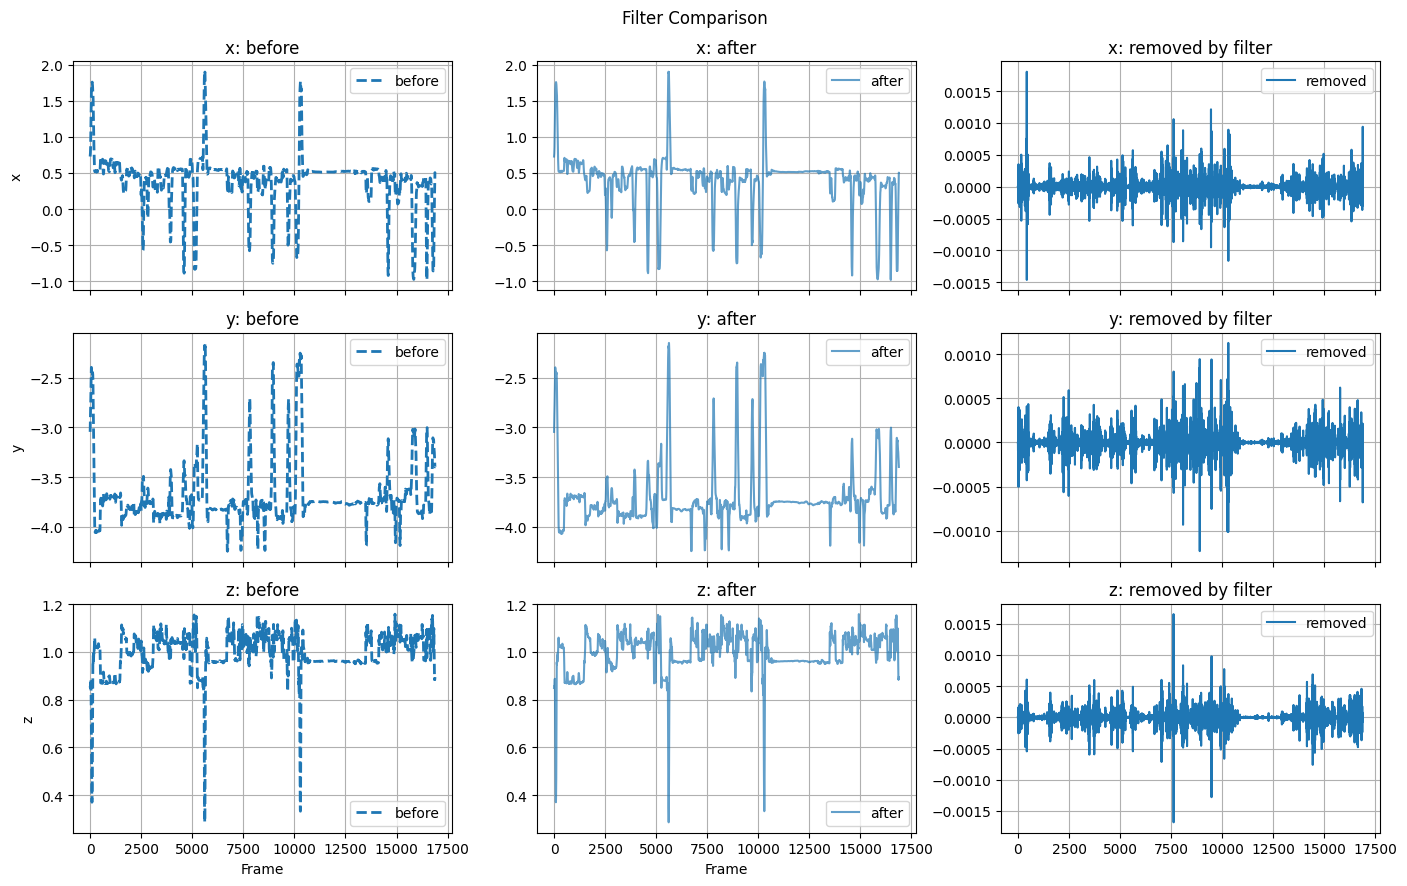

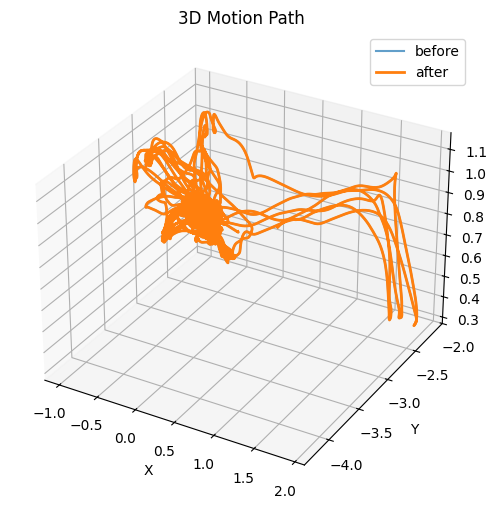

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from src.preprocessing.filters import lowpass_filter
from src.io.helpers.helpers_my_signal import get_signal
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


def plot_before_after_with_removed(raw: np.ndarray, filtered: np.ndarray, title: str = "Before vs After"):
    raw = np.asarray(raw, dtype=float)
    filtered = np.asarray(filtered, dtype=float)

    if raw.shape != filtered.shape:
        raise ValueError(f"Shape mismatch: raw {raw.shape}, filtered {filtered.shape}")

    if raw.ndim == 1:
        raw = raw[:, None]
        filtered = filtered[:, None]

    removed = raw - filtered
    n_frames, n_dims = raw.shape
    labels = ["x", "y", "z"][:n_dims]
    if n_dims > 3:
        labels = [f"dim_{i}" for i in range(n_dims)]

    t = np.arange(n_frames)

    fig, axes = plt.subplots(n_dims, 3, figsize=(14, 3 * n_dims), sharex=True)

    if n_dims == 1:
        axes = np.array([axes])

    for i in range(n_dims):
        axes[i, 0].plot(t, raw[:, i], '--', label="before", linewidth=2, alpha=1.0)
        #axes[i, 0].plot(t, filtered[:, i], marker='o', label="after", alpha= 0.7)
        axes[i, 0].set_ylabel(labels[i])
        axes[i, 0].set_title(f"{labels[i]}: before")
        axes[i, 0].grid(True)
        axes[i, 0].legend()

        axes[i, 1].plot(t, filtered[:, i],'-', label="after", alpha= 0.7)
        axes[i, 1].set_title(f"{labels[i]}: after")
        axes[i, 1].grid(True)
        axes[i, 1].legend()

        axes[i, 2].plot(t, removed[:, i], label="removed")
        axes[i, 2].set_title(f"{labels[i]}: removed by filter")
        axes[i, 2].grid(True)
        axes[i, 2].legend()

    axes[-1, 0].set_xlabel("Frame")
    axes[-1, 1].set_xlabel("Frame")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

    
def plot_3d_before_after(raw: np.ndarray, filtered: np.ndarray, title: str = "3D Motion Path"):
    raw = np.asarray(raw, dtype=float)
    filtered = np.asarray(filtered, dtype=float)

    if raw.shape != filtered.shape or raw.ndim != 2 or raw.shape[1] != 3:
        raise ValueError("Both raw and filtered must have shape (N, 3).")

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")

    ax.plot(raw[:, 0], raw[:, 1], raw[:, 2], label="before", alpha=0.7)
    ax.plot(filtered[:, 0], filtered[:, 1], filtered[:, 2], label="after", linewidth=2)

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title(title)
    ax.legend()
    plt.show()

    


path = Path("../tests/sample_data/sample_xsens.csv")
signal = get_signal(path)

filtered_signal = lowpass_filter(signal, fps=40, cutoff=8)
plot_before_after_with_removed(signal, filtered_signal, title="Filter Comparison")
plot_3d_before_after(signal, filtered_signal)